# Study v2: referral funnel and incident timing

Formal decisions show what reached the stewards. Public Race Control messages add part of the path
from noted, to investigated, to decided. The feed is still not the universe of every on-track act.

In [1]:
# ruff: noqa: E402
import json
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

STRICT = ROOT / "data/manual/study_v2_strict_model_audit/strict-model-audit-0fe15fd6b052"
REVIEW = ROOT / "data/manual/study_v2_review_packets/study-v2-review-7cb1b29b5251"
REFERRAL = ROOT / "data/manual/study_v2_referrals/referrals-a4f9bd038101"
CLOCK = ROOT / "data/manual/study_v2_incident_clock/incident-clock-3dc8bb350308"
CONTEXT = ROOT / "data/manual/study_v2_incident_context/incident-context-707a44aafeb4"
CLOSE = ROOT / "data/manual/study_v2_close_cases/close-cases-b175fe03fa80"
DAMAGE = ROOT / "data/manual/study_v2_damage/damage-screening-23c77a57134e"
LAYERS = ROOT / "data/manual/study_v2_layers/study-v2-layers-eed6774fb6c5"
NATIONALITY = ROOT / "data/manual/study_v2_nationality/nationality-diagnostic-2b1b0ffdd961"
GENERATED = ROOT / "reports/generated/study_v2"
GENERATED.mkdir(parents=True, exist_ok=True)

In [2]:
referral_manifest = json.loads((REFERRAL / "manifest.json").read_text(encoding="utf-8"))
clock_manifest = json.loads((CLOCK / "manifest.json").read_text(encoding="utf-8"))
context_manifest = json.loads((CONTEXT / "manifest.json").read_text(encoding="utf-8"))
funnel = pd.read_csv(REFERRAL / "referral_funnel.csv")
display(funnel)
display(pd.DataFrame([referral_manifest, clock_manifest, context_manifest]).T)
assert referral_manifest["high_confidence_link_count"] == 177
assert clock_manifest["known_validation_contained_count"] == 31
assert clock_manifest["known_validation_case_count"] == 31

,stage,count
0,Race/Sprint Race Control messages,16039
1,Process-state messages parsed,1815
2,Referral episodes,966
3,Episodes linked to a primary adjudication,281
4,Primary adjudications,346
5,High-confidence adjudication links,177
6,Adjudication links pending review,153
7,Unmatched primary adjudications,16


,0,1,2
created_at,2026-08-14T01:08:07.454856+00:00,2026-08-13T22:27:11.356874+00:00,2026-08-14T01:08:07.809698+00:00
episode_count,966.0,NaN,NaN
episodes_sha256,c761abdfd6d632c223c149174e05f6b502d770f8b85b1a...,NaN,NaN
high_confidence_link_count,177.0,NaN,NaN
human_validation_complete,False,False,False
limitation,"The feed observes public process messages, not...",Minute-only FIA clocks define a one-minute unc...,Context extraction preserves explicit source p...
links_sha256,3c8e1bec82140863bd32b63b97e9fe4433f612cc0c5be6...,NaN,NaN
parsed_message_count,1815.0,NaN,NaN
parsed_messages_sha256,5515622bfab0c4d28a9fbff3892133bc2c2d4e7278f504...,NaN,NaN
pending_link_count,153.0,NaN,NaN


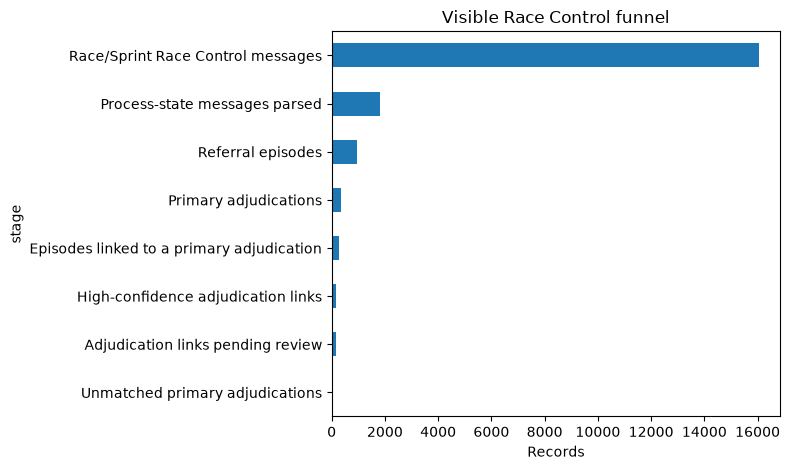

In [3]:
plot = funnel.sort_values("count", ascending=True)
ax = plot.plot.barh(x="stage", y="count", legend=False, figsize=(8, 4.8))
ax.set(title="Visible Race Control funnel", xlabel="Records")
plt.tight_layout()
plt.savefig(GENERATED / "referral_funnel.png", dpi=160, bbox_inches="tight")
plt.show()

The clock mapping resolves 338 of 346 FIA incident times to a lap window. It contains all 31 cases
with a previously known lap. It produces 174 single-lap candidates and keeps wider windows as
uncertain. High-confidence referral links are usable descriptively; weaker links wait for review.